# 2 Заход

In [1]:
import os
import glob
import cv2
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras import layers, models


In [2]:
DATA_ROOT = r"C:\Users\maxim\vision\archive"
FRAMES_DIR = os.path.join(DATA_ROOT, "frames")
MASKS_DIR  = os.path.join(DATA_ROOT, "masks")

IMG_SIZE = 256
BATCH_SIZE = 8
EPOCHS = 50
AUTOTUNE = tf.data.AUTOTUNE


In [3]:
MODELS_DIR = "models"
os.makedirs(MODELS_DIR, exist_ok=True)


1. Загрузка изображений и масок

In [4]:
def load_pair(img_path):
    img_path = img_path.numpy().decode("utf-8")
    mask_path = os.path.join(MASKS_DIR, os.path.basename(img_path))

    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    img = img.astype(np.float32) / 255.0
    img = img[..., None]

    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    mask = cv2.resize(mask, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_NEAREST)
    mask = (mask > 0).astype(np.float32)
    mask = mask[..., None]

    return img, mask


In [5]:
def tf_load_pair(path):
    img, mask = tf.py_function(
        load_pair,
        [path],
        [tf.float32, tf.float32]
    )
    img.set_shape((IMG_SIZE, IMG_SIZE, 1))
    mask.set_shape((IMG_SIZE, IMG_SIZE, 1))
    return img, mask


2. Аугментация (БЕЗ addons)

In [6]:
def augment(img, mask):
    if tf.random.uniform(()) > 0.5:
        img = tf.image.flip_left_right(img)
        mask = tf.image.flip_left_right(mask)

    if tf.random.uniform(()) > 0.5:
        img = tf.image.flip_up_down(img)
        mask = tf.image.flip_up_down(mask)

    return img, mask


3. Train / Validation split

In [7]:
all_images = sorted(glob.glob(os.path.join(FRAMES_DIR, "*")))
np.random.shuffle(all_images)

split = int(0.8 * len(all_images))
train_imgs = all_images[:split]
val_imgs   = all_images[split:]


4. tf.data.Dataset

In [8]:
train_ds = (
    tf.data.Dataset.from_tensor_slices(train_imgs)
    .map(tf_load_pair, num_parallel_calls=AUTOTUNE)
    .map(augment, num_parallel_calls=AUTOTUNE)
    .shuffle(128)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

val_ds = (
    tf.data.Dataset.from_tensor_slices(val_imgs)
    .map(tf_load_pair, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)


5. Метрика Dice

In [9]:
def dice_coef(y_true, y_pred, smooth=1e-6):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)
    y_pred = tf.clip_by_value(y_pred, 0.0, 1.0)

    intersection = tf.reduce_sum(y_true * y_pred)
    union = tf.reduce_sum(y_true) + tf.reduce_sum(y_pred)

    return (2.0 * intersection + smooth) / (union + smooth)


6. Fourier Features слой

In [10]:
class FourierFeatures(tf.keras.layers.Layer):
    def __init__(self, num_features=64, scale=10.0, **kwargs):
        super().__init__(**kwargs)
        self.num_features = num_features
        self.scale = scale

    def build(self, input_shape):
        self.B = self.add_weight(
            name="B",
            shape=(input_shape[-1], self.num_features),
            initializer=tf.keras.initializers.RandomNormal(stddev=self.scale),
            trainable=True
        )

    def call(self, x):
        x_proj = 2.0 * np.pi * tf.matmul(x, self.B)
        return tf.concat([tf.sin(x_proj), tf.cos(x_proj)], axis=-1)

    def get_config(self):
        config = super().get_config()
        config.update({
            "num_features": self.num_features,
            "scale": self.scale
        })
        return config


7. U-Net блоки

In [11]:
def conv_block(x, filters):
    x = layers.Conv2D(filters, 3, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    x = layers.Conv2D(filters, 3, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    return x


8. Модель 1 — U-Net (Baseline)

In [12]:
def UNet_baseline():
    inputs = layers.Input((IMG_SIZE, IMG_SIZE, 1))

    c1 = conv_block(inputs, 32)
    p1 = layers.MaxPooling2D()(c1)

    c2 = conv_block(p1, 64)
    p2 = layers.MaxPooling2D()(c2)

    c3 = conv_block(p2, 128)

    u1 = layers.UpSampling2D()(c3)
    u1 = layers.Concatenate()([u1, c2])
    c4 = conv_block(u1, 64)

    u2 = layers.UpSampling2D()(c4)
    u2 = layers.Concatenate()([u2, c1])
    c5 = conv_block(u2, 32)

    outputs = layers.Conv2D(1, 1, activation="sigmoid")(c5)

    return models.Model(inputs, outputs)


9. Модель 2 — U-Net + Fourier Features

In [13]:
def UNet_fourier(input_shape=(256, 256, 1)):
    inputs = layers.Input(input_shape)

    x = FourierFeatures(num_features=64, scale=10.0, name="fourier_features")(inputs)

    c1 = conv_block(x, 32)
    p1 = layers.MaxPooling2D()(c1)

    c2 = conv_block(p1, 64)
    p2 = layers.MaxPooling2D()(c2)

    c3 = conv_block(p2, 128)
    p3 = layers.MaxPooling2D()(c3)

    c4 = conv_block(p3, 256)

    u1 = layers.UpSampling2D()(c4)
    u1 = layers.Concatenate()([u1, c3])
    c5 = conv_block(u1, 128)

    u2 = layers.UpSampling2D()(c5)
    u2 = layers.Concatenate()([u2, c2])
    c6 = conv_block(u2, 64)

    u3 = layers.UpSampling2D()(c6)
    u3 = layers.Concatenate()([u3, c1])
    c7 = conv_block(u3, 32)

    outputs = layers.Conv2D(1, 1, activation="sigmoid")(c7)

    return models.Model(inputs, outputs, name="UNet_Fourier")


10. Обучение моделей

In [14]:
callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        filepath=os.path.join(MODELS_DIR, "unet_baseline_best.keras"),
        monitor="val_dice_coef",
        mode="max",
        save_best_only=True,
        verbose=1
    )
]

In [24]:
model_base = UNet_baseline()
model_base.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss="binary_crossentropy",
    metrics=[dice_coef]
)

history_base = model_base.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50,
    callbacks=callbacks
)


Epoch 1/50
273/273 ━━━━━━━━━━━━━━━━━━━━ 0s 988ms/step - dice_coef: 0.0359 - loss: 0.4358
Epoch 1: val_dice_coef did not improve from 0.76038
273/273 ━━━━━━━━━━━━━━━━━━━━ 297s 1s/step - dice_coef: 0.0344 - loss: 0.3282 - val_dice_coef: 0.0287 - val_loss: 0.2801 - learning_rate: 1.0000e-04
Epoch 2/50
273/273 ━━━━━━━━━━━━━━━━━━━━ 0s 985ms/step - dice_coef: 0.0390 - loss: 0.2235
Epoch 2: val_dice_coef did not improve from 0.76038
273/273 ━━━━━━━━━━━━━━━━━━━━ 287s 1s/step - dice_coef: 0.0403 - loss: 0.2072 - val_dice_coef: 0.0397 - val_loss: 0.2013 - learning_rate: 1.0000e-04
Epoch 3/50
273/273 ━━━━━━━━━━━━━━━━━━━━ 0s 956ms/step - dice_coef: 0.0533 - loss: 0.1685
Epoch 3: val_dice_coef did not improve from 0.76038

Epoch 3: ReduceLROnPlateau reducing learning rate to 2.9999999242136255e-05.
273/273 ━━━━━━━━━━━━━━━━━━━━ 279s 1s/step - dice_coef: 0.0580 - loss: 0.1586 - val_dice_coef: 0.0758 - val_loss: 0.1494 - learning_rate: 1.0000e-04
Epoch 4/50
273/273 ━━━━━━━━━━━━━━━━━━━━ 0s 976ms/step -

# fourier

In [14]:
callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        filepath=os.path.join(MODELS_DIR, "unet_fourier_best.keras"),
        monitor="val_dice_coef",
        mode="max",
        save_best_only=True,
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_dice_coef",
        factor=0.3,
        patience=3,
        min_lr=1e-6,
        mode="max",
        verbose=1
    )
]


In [15]:
model_fourier = UNet_fourier()

model_fourier.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="binary_crossentropy",
    metrics=[dice_coef]
)


In [16]:
history_fourier = model_fourier.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks
)


Epoch 1/50
273/273 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - dice_coef: 0.0333 - loss: 0.4504
Epoch 1: val_dice_coef improved from None to 0.03626, saving model to models\unet_fourier_best.keras
273/273 ━━━━━━━━━━━━━━━━━━━━ 493s 2s/step - dice_coef: 0.0349 - loss: 0.3196 - val_dice_coef: 0.0363 - val_loss: 0.3906 - learning_rate: 1.0000e-04
Epoch 2/50
273/273 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - dice_coef: 0.0575 - loss: 0.1986
Epoch 2: val_dice_coef improved from 0.03626 to 0.09094, saving model to models\unet_fourier_best.keras
273/273 ━━━━━━━━━━━━━━━━━━━━ 453s 2s/step - dice_coef: 0.0641 - loss: 0.1819 - val_dice_coef: 0.0909 - val_loss: 0.1627 - learning_rate: 1.0000e-04
Epoch 3/50
273/273 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - dice_coef: 0.0899 - loss: 0.1437
Epoch 3: val_dice_coef improved from 0.09094 to 0.12932, saving model to models\unet_fourier_best.keras
273/273 ━━━━━━━━━━━━━━━━━━━━ 523s 2s/step - dice_coef: 0.0959 - loss: 0.1344 - val_dice_coef: 0.1293 - val_loss: 0.1295 - learning_rate: 

In [ ]:
# # Загрузить модели
# model_base = tf.keras.models.load_model(
#     "models/unet_baseline_best.keras",
#     custom_objects={"dice_coef": dice_coef}
# )

# model_fourier = tf.keras.models.load_model(
#     "models/unet_fourier_best.keras",
#     custom_objects={
#         "dice_coef": dice_coef,
#         "FourierFeatures": FourierFeatures
#     }
# )

11. Визуализация результатов

In [18]:
def visualize_prediction(model, dataset, n=8):
    for imgs, masks in dataset.take(1):
        preds = model.predict(imgs)

        for i in range(n):
            plt.figure(figsize=(12,4))

            plt.subplot(1,3,1)
            plt.title("CT")
            plt.imshow(imgs[i,...,0], cmap="gray")
            plt.axis("off")

            plt.subplot(1,3,2)
            plt.title("GT")
            plt.imshow(masks[i,...,0], cmap="gray")
            plt.axis("off")

            plt.subplot(1,3,3)
            plt.title("Prediction")
            plt.imshow(preds[i,...,0] > 0.5, cmap="gray")
            plt.axis("off")

            plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 306ms/step


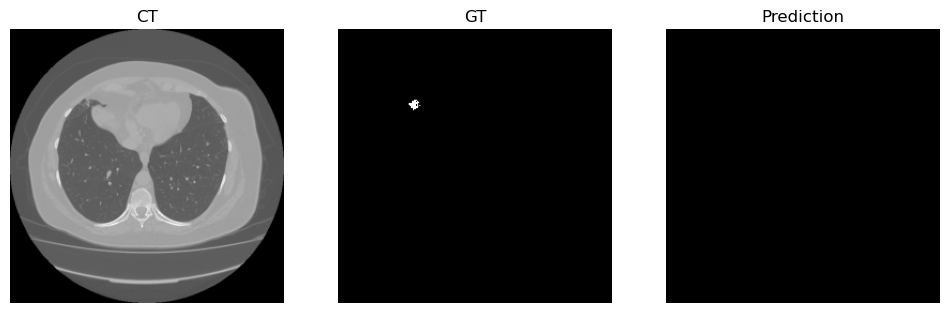

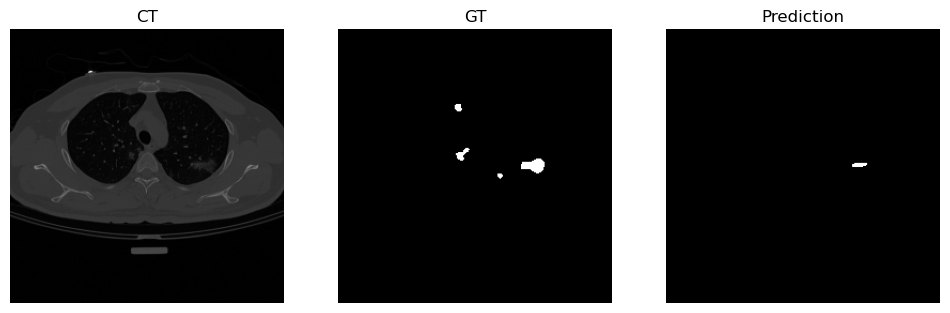

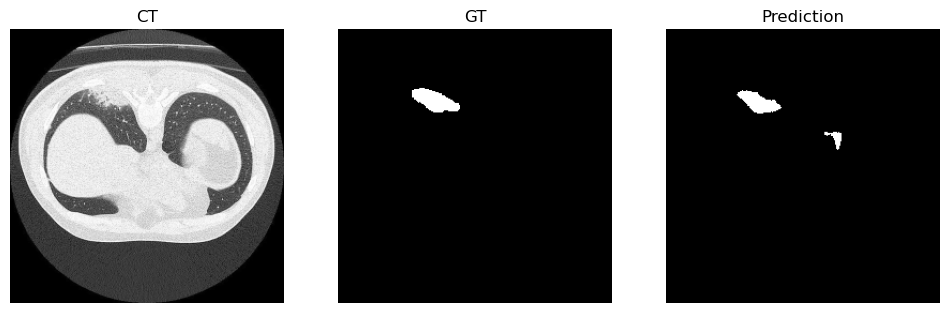

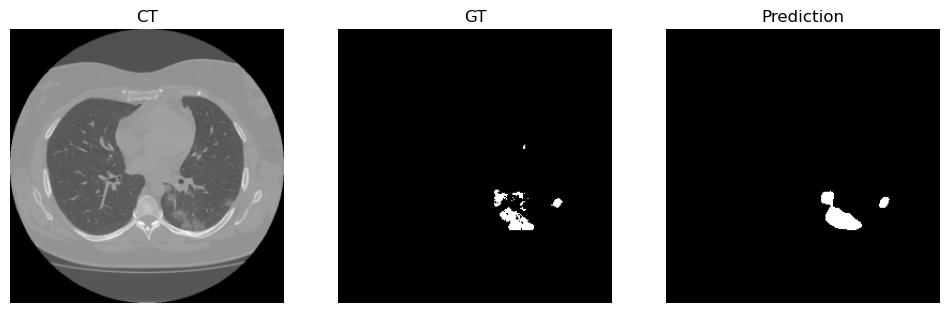

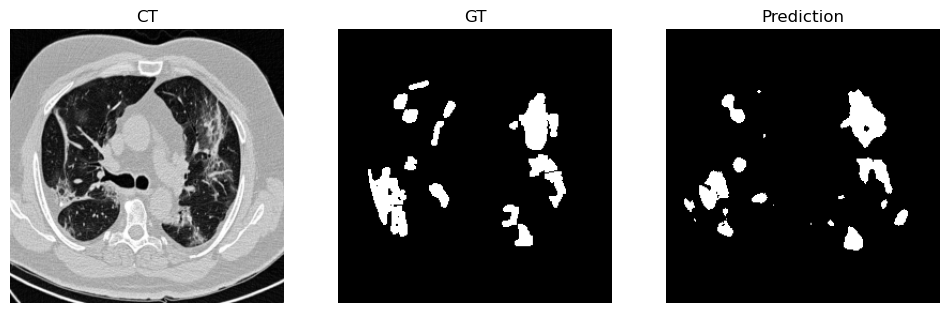

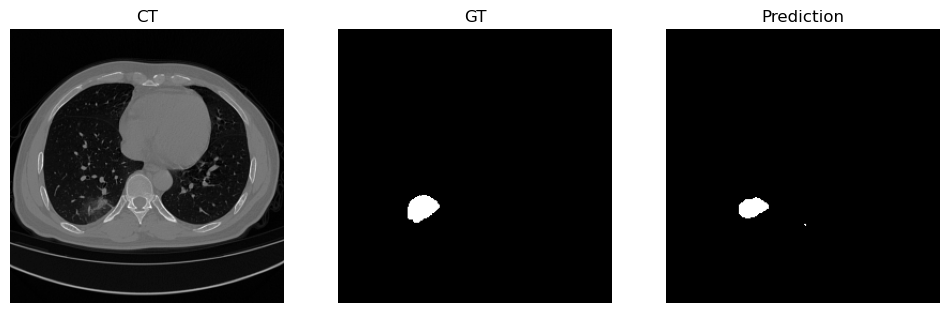

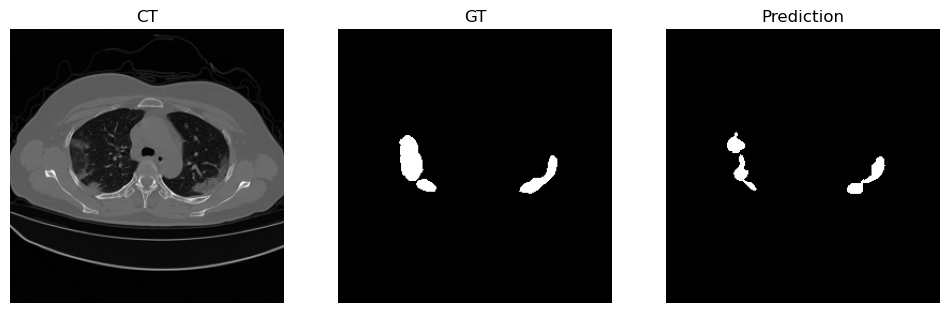

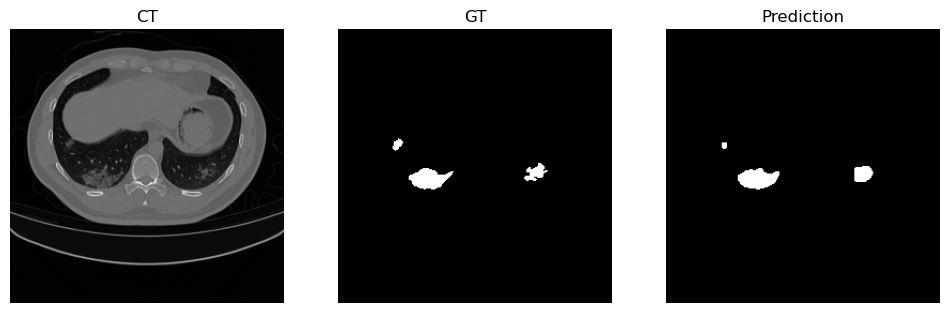

In [27]:
visualize_prediction(model_base, val_ds)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 965ms/step


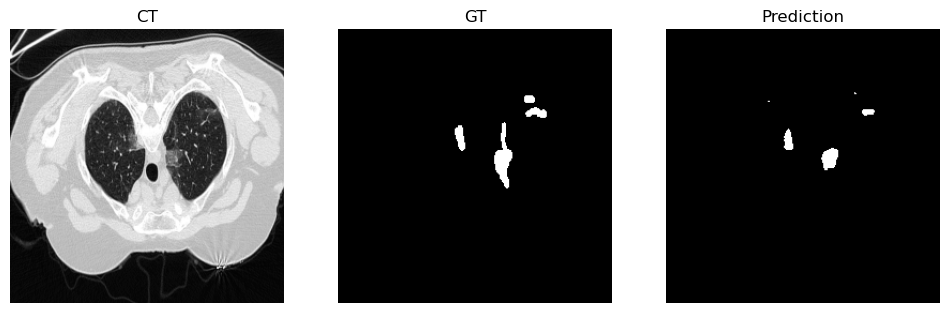

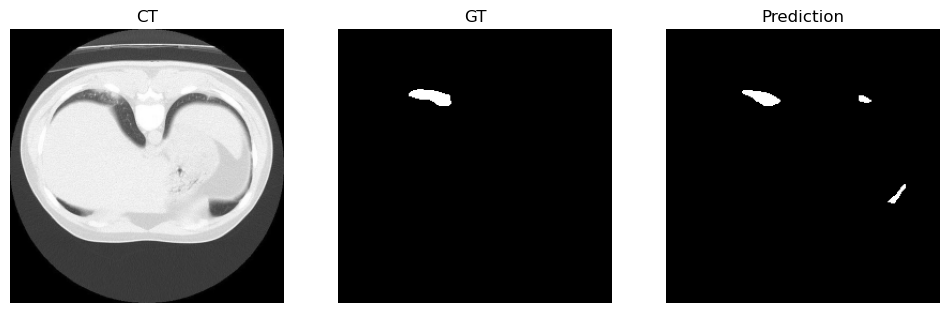

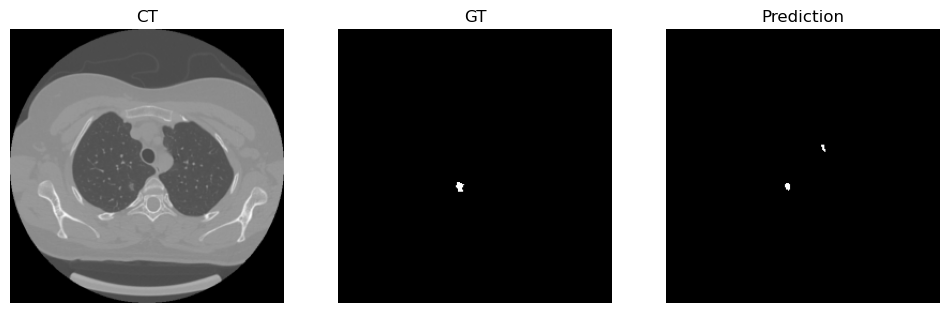

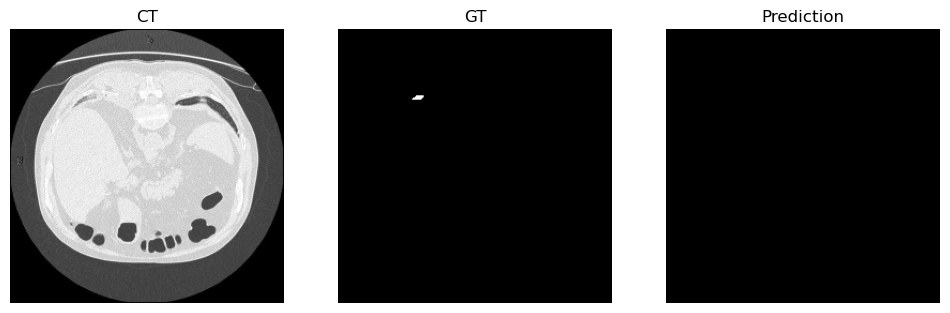

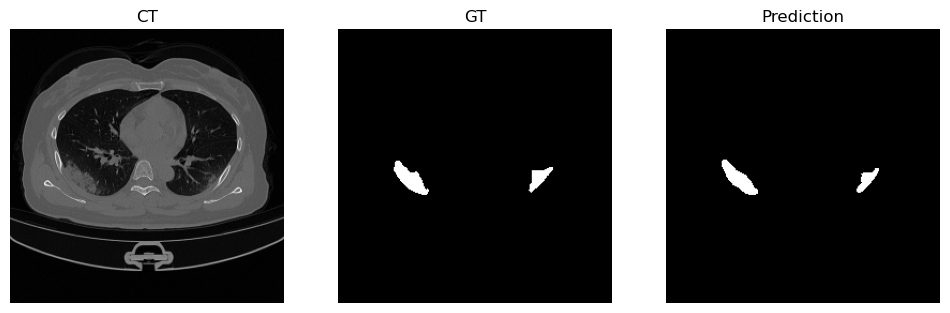

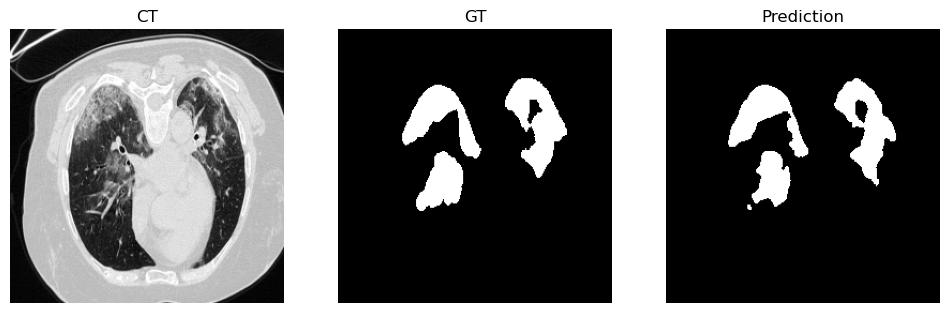

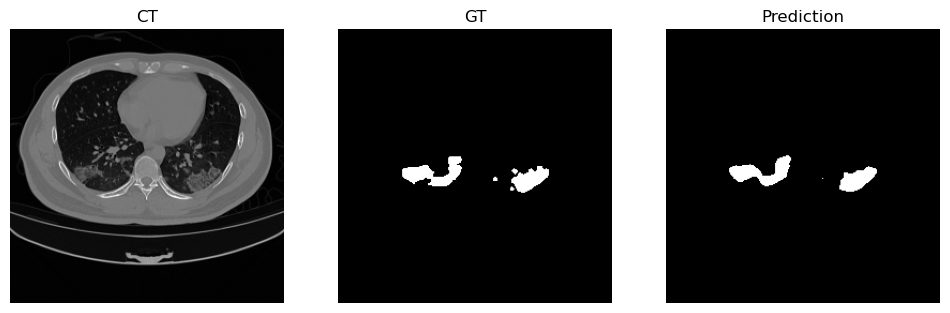

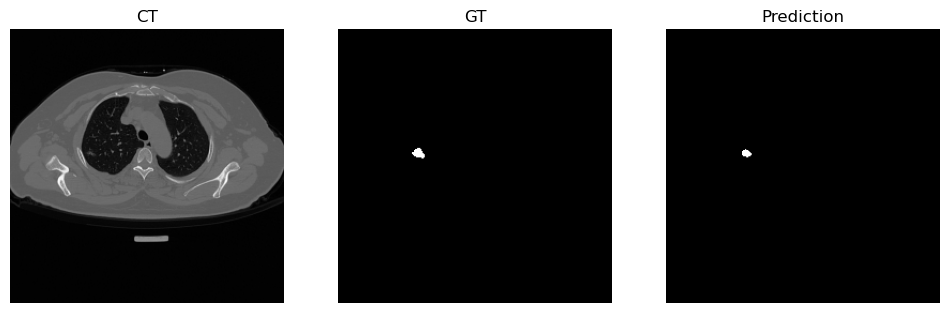

In [19]:
visualize_prediction(model_fourier, val_ds)

12. Графики обучения

In [20]:
def plot_history(h1, h2):
    plt.figure(figsize=(10,4))

    plt.subplot(1,2,1)
    plt.title("Train Dice")
    plt.plot(h1.history["dice_coef"], label="Baseline")
    plt.plot(h2.history["dice_coef"], label="Fourier")
    plt.legend()

    plt.subplot(1,2,2)
    plt.title("Val Dice")
    plt.plot(h1.history["val_dice_coef"], label="Baseline")
    plt.plot(h2.history["val_dice_coef"], label="Fourier")
    plt.legend()

    plt.show()


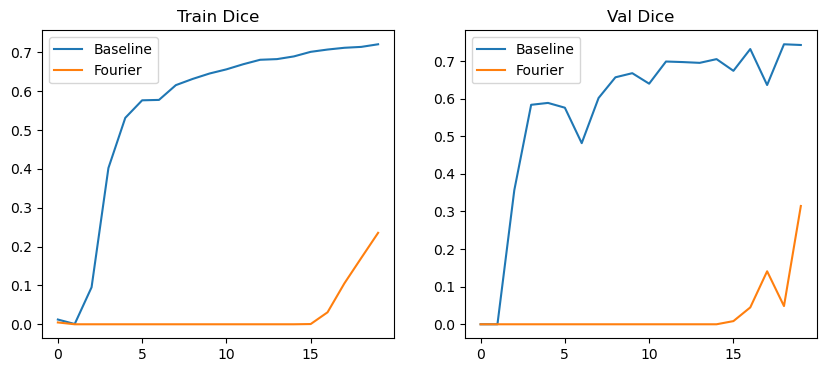

In [21]:
plot_history(history_base, history_fourier)

In [22]:
def plot_history(h2):
    plt.figure(figsize=(10,4))

    plt.subplot(1,2,1)
    plt.title("Train Dice")
    plt.plot(h2.history["dice_coef"], label="Fourier")
    plt.legend()

    plt.subplot(1,2,2)
    plt.title("Val Dice")
    plt.plot(h2.history["val_dice_coef"], label="Fourier")
    plt.legend()

    plt.show()


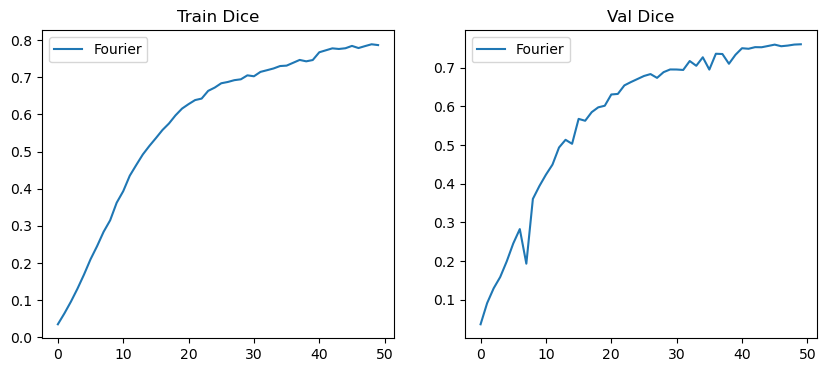

In [23]:
plot_history(history_fourier)
